# XGBoost-Hyperparameterexperimente – Porto Seguro

Dieses Notebook untersucht die wichtigsten XGBoost-Hyperparameter in einer
nachvollziehbaren Reihenfolge. Im Mittelpunkt steht nicht nur die beste
Parameterkombination, sondern die Frage, **welche Modellwirkung eine Veränderung
auslöst**.

Untersucht werden:

1. `learning_rate` zusammen mit Early Stopping und der benötigten Baumzahl
2. `max_depth × min_child_weight`
3. `gamma`, `reg_alpha` und `reg_lambda`
4. `subsample × colsample_bytree`
5. `scale_pos_weight` und `max_delta_step`
6. `grow_policy × max_leaves`
7. `max_bin`
8. One-Hot-Encoding, Target Encoding und native Kategorien
9. eine abschließende Randomized Search

Der Testsplit wird erst im letzten Abschnitt verwendet. Alle vorherigen
Entscheidungen beruhen ausschließlich auf Trainings- und Validierungsdaten.

## Hinweise vor dem Start

- Standardmäßig läuft das Notebook im Modus **`normal`** auf einer stratifizierten
  Teilmenge des Trainingssplits.
- `quick` dient nur als technischer Probelauf.
- `full` verwendet den gesamten Trainingssplit und eine größere Parametersuche.
- Die vollständige Ausführung kann – abhängig von Hardware und Laufmodus –
  deutlich länger dauern.
- ROC-AUC bzw. normalisierter Gini sind die primären Auswahlmetriken. Wegen der
  niedrigen Positivrate werden zusätzlich Average Precision, Log-Loss und
  Brier-Score dokumentiert.

Dokumentation:
[XGBoost Parameters](https://xgboost.readthedocs.io/en/stable/parameter.html) ·
[XGBoost Tree Methods](https://xgboost.readthedocs.io/en/stable/treemethod.html)

In [1]:
# Optional bei einer frischen Umgebung ausführen:
# %pip install -q xgboost scikit-learn scipy pandas matplotlib

import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Konfiguration

In [2]:
RANDOM_STATE = 42

# quick: technischer Test | normal: empfohlener Projektlauf | full: maximale Auswertung
RUN_MODE = os.getenv("XGB_RUN_MODE", "normal").lower()
if RUN_MODE not in {"quick", "normal", "full"}:
    raise ValueError("RUN_MODE muss 'quick', 'normal' oder 'full' sein.")

MODE_CONFIG = {
    "quick":  {"experiment_fraction": 0.05, "search_iter": 8,  "cv_splits": 2},
    "normal": {"experiment_fraction": 0.25, "search_iter": 25, "cv_splits": 3},
    "full":   {"experiment_fraction": 1.00, "search_iter": 50, "cv_splits": 5},
}
CFG = MODE_CONFIG[RUN_MODE]

RUN_RANDOM_SEARCH = True
RUN_ENCODING_COMPARISON = True
RUN_ADVANCED_APPENDIX = False  # DART und zusätzliche Column-Sampling-Varianten

OUTPUT_DIR = Path("xgboost_hyperparameter_experimente_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Laufmodus:", RUN_MODE)
print(CFG)

Laufmodus: normal
{'experiment_fraction': 0.25, 'search_iter': 25, 'cv_splits': 3}


## 2. Daten laden und Zielvariable vorbereiten

In [3]:
t0 = time.perf_counter()
df = fetch_openml(data_id=42742, as_frame=True).frame
df["target"] = pd.to_numeric(df["target"].astype(str)).astype("int8")

feature_cols = [c for c in df.columns if c not in {"target", "id"}]
cat_cols = [c for c in feature_cols if c.endswith("_cat")]
bin_cols = [c for c in feature_cols if c.endswith("_bin")]
num_cols = [c for c in feature_cols if c not in cat_cols + bin_cols]

X = df[feature_cols].copy()
y = df["target"].to_numpy()

# -1 kennzeichnet in Porto Seguro fehlende Werte.
X[num_cols] = (
    X[num_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace(-1, np.nan)
    .astype("float32")
)
X[bin_cols] = X[bin_cols].apply(pd.to_numeric, errors="coerce").astype("float32")
X[cat_cols] = X[cat_cols].astype("string").fillna("__MISSING__")

print(f"Geladen in {time.perf_counter() - t0:.1f} s")
print(f"Form: {X.shape[0]:,} Zeilen × {X.shape[1]} Features")
print(f"Positivrate: {y.mean():.3%}")
print(f"Klassenverhältnis 0:1 = {(y == 0).sum() / (y == 1).sum():.2f}:1")
print(f"Numerisch/ordinal: {len(num_cols)} | binär: {len(bin_cols)} | kategorial: {len(cat_cols)}")

Geladen in 6.7 s
Form: 595,212 Zeilen × 57 Features
Positivrate: 3.645%
Klassenverhältnis 0:1 = 26.44:1
Numerisch/ordinal: 26 | binär: 17 | kategorial: 14


## 3. Reproduzierbarer 80/10/10-Split

Falls im Projektordner bereits gemeinsame Split-Indizes liegen, werden sie
wiederverwendet. Andernfalls werden sie einmalig erzeugt. Dadurch lassen sich
die Resultate später sauber mit anderen Modellen vergleichen.

In [4]:
split_candidates = [
    Path("data") / "processed",
    Path("..") / ".." / ".." / "data" / "processed",
]
split_files = ["train_idx.npy", "val_idx.npy", "test_idx.npy"]
SPLIT_DIR = next(
    (p for p in split_candidates if all((p / f).exists() for f in split_files)),
    split_candidates[0],
)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

paths = {name: SPLIT_DIR / f"{name}_idx.npy" for name in ["train", "val", "test"]}
if all(p.exists() for p in paths.values()):
    idx_train, idx_val, idx_test = [np.load(paths[n]) for n in ["train", "val", "test"]]
    if max(map(np.max, [idx_train, idx_val, idx_test])) >= len(X):
        raise ValueError("Vorhandene Split-Indizes passen nicht zum geladenen Datensatz.")
    print("Vorhandene Split-Indizes geladen aus:", SPLIT_DIR.resolve())
else:
    all_idx = np.arange(len(y))
    idx_train, idx_rest = train_test_split(
        all_idx, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    idx_val, idx_test = train_test_split(
        idx_rest, test_size=0.50, stratify=y[idx_rest], random_state=RANDOM_STATE
    )
    for name, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
        np.save(paths[name], idx)
    print("Neue Split-Indizes gespeichert unter:", SPLIT_DIR.resolve())

X_train_raw, y_train = X.iloc[idx_train].copy(), y[idx_train]
X_val_raw, y_val = X.iloc[idx_val].copy(), y[idx_val]
X_test_raw, y_test = X.iloc[idx_test].copy(), y[idx_test]

print(f"Train: {len(X_train_raw):,} | Validierung: {len(X_val_raw):,} | Test: {len(X_test_raw):,}")

Vorhandene Split-Indizes geladen aus: C:\data\processed
Train: 476,169 | Validierung: 59,521 | Test: 59,522


## 4. Einheitliche Experimentstichprobe und One-Hot-Encoding

Alle Hyperparameterexperimente verwenden dieselben Beobachtungen und dieselbe
Merkmalsdarstellung. So können Unterschiede tatsächlich den Hyperparametern
zugeordnet werden. Das One-Hot-Encoding verwendet keine Zielinformation und wird
nur auf den jeweiligen Trainingsdaten angepasst.

In [5]:
frac = CFG["experiment_fraction"]
if frac < 1.0:
    X_exp_raw, _, y_exp, _ = train_test_split(
        X_train_raw,
        y_train,
        train_size=frac,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_exp_raw, y_exp = X_train_raw.copy(), y_train.copy()

onehot = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=50,
                sparse_output=True,
            ),
            cat_cols,
        ),
        ("num", "passthrough", num_cols + bin_cols),
    ],
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

t0 = time.perf_counter()
X_exp = onehot.fit_transform(X_exp_raw)
X_val = onehot.transform(X_val_raw)
print(f"Experimentdaten: {X_exp.shape[0]:,} Zeilen × {X_exp.shape[1]} Spalten")
print(f"Encoding-Dauer: {time.perf_counter() - t0:.1f} s")

Experimentdaten: 119,042 Zeilen × 226 Spalten
Encoding-Dauer: 1.4 s


## 5. Gemeinsame Messfunktion

In [6]:
BASE_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.035,
    max_depth=2,
    min_child_weight=30,
    subsample=0.80,
    colsample_bytree=0.80,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

RESULTS = []
MODELS = {}


def gini(y_true, score):
    return 2 * roc_auc_score(y_true, score) - 1


def build_record(group, name, y_tr, p_tr, y_va, p_va, elapsed, model, params):
    auc_tr = roc_auc_score(y_tr, p_tr)
    auc_va = roc_auc_score(y_va, p_va)
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is not None:
        best_iteration = int(best_iteration)
    return {
        "Gruppe": group,
        "Konfiguration": name,
        "AUC Train": auc_tr,
        "AUC Val": auc_va,
        "Gini Val": 2 * auc_va - 1,
        "Average Precision Val": average_precision_score(y_va, p_va),
        "Log-Loss Val": log_loss(y_va, np.clip(p_va, 1e-7, 1 - 1e-7)),
        "Brier Val": brier_score_loss(y_va, p_va),
        "Train-Val-Abstand": auc_tr - auc_va,
        "beste Iteration": best_iteration,
        "Fit-Zeit [s]": elapsed,
        "Parameter": json.dumps(params, sort_keys=True, default=str),
    }


def run_experiment(group, name, overrides=None, early_stopping=False, verbose=False):
    params = {**BASE_PARAMS, **(overrides or {})}
    if early_stopping:
        params.setdefault("n_estimators", 4000)
        params["early_stopping_rounds"] = 50

    model = XGBClassifier(**params)
    fit_kwargs = {}
    if early_stopping:
        fit_kwargs["eval_set"] = [(X_val, y_val)]
        fit_kwargs["verbose"] = False

    t0 = time.perf_counter()
    model.fit(X_exp, y_exp, **fit_kwargs)
    elapsed = time.perf_counter() - t0

    p_train = model.predict_proba(X_exp)[:, 1]
    p_val = model.predict_proba(X_val)[:, 1]
    record = build_record(
        group, name, y_exp, p_train, y_val, p_val, elapsed, model, params
    )
    RESULTS.append(record)
    MODELS[(group, name)] = model

    if verbose:
        print(
            f"{name:<34} Val-AUC {record['AUC Val']:.4f} | "
            f"Gap {record['Train-Val-Abstand']:+.4f} | {elapsed:.1f} s"
        )
    return model, record


def group_table(group):
    cols = [
        "Konfiguration", "AUC Train", "AUC Val", "Gini Val",
        "Average Precision Val", "Log-Loss Val", "Brier Val",
        "Train-Val-Abstand", "beste Iteration", "Fit-Zeit [s]",
    ]
    return pd.DataFrame([r for r in RESULTS if r["Gruppe"] == group])[cols]


def save_results():
    result_df = pd.DataFrame(RESULTS)
    result_df.to_csv(OUTPUT_DIR / "alle_experimente.csv", index=False)
    return result_df

## 6. Referenzmodell

In [7]:
_, baseline_record = run_experiment(
    "Referenz", "Referenzkonfiguration", verbose=True
)
pd.DataFrame([baseline_record]).drop(columns="Parameter").round(4)

Referenzkonfiguration              Val-AUC 0.6288 | Gap +0.0282 | 2.2 s


,Gruppe,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
0,Referenz,Referenzkonfiguration,0.657,0.6288,0.2576,0.0632,0.1526,0.0348,0.0282,None,2.2143


## 7. Lernrate und benötigte Baumzahl

Jede Lernrate erhält dieselbe hohe Obergrenze für `n_estimators`. Early Stopping
bestimmt, wie viele Boosting-Runden tatsächlich benötigt werden. Dadurch wird
vermieden, eine kleine Lernrate nur deshalb schlecht zu bewerten, weil das
Training nach einer festen, zu kleinen Baumzahl endet.

In [8]:
for lr in [0.20, 0.10, 0.05, 0.02, 0.01]:
    max_rounds = 5000 if lr <= 0.02 else 3000
    run_experiment(
        "Lernrate",
        f"learning_rate={lr}",
        {"learning_rate": lr, "n_estimators": max_rounds},
        early_stopping=True,
        verbose=True,
    )

learning_df = group_table("Lernrate").sort_values("AUC Val", ascending=False)
learning_df.round(4)

learning_rate=0.2                  Val-AUC 0.6275 | Gap +0.0221 | 7.5 s
learning_rate=0.1                  Val-AUC 0.6299 | Gap +0.0229 | 10.6 s
learning_rate=0.05                 Val-AUC 0.6288 | Gap +0.0293 | 23.6 s
learning_rate=0.02                 Val-AUC 0.6301 | Gap +0.0203 | 33.5 s
learning_rate=0.01                 Val-AUC 0.6299 | Gap +0.0270 | 86.0 s


,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
3,learning_rate=0.02,0.6504,0.6301,0.2601,0.0635,0.1525,0.0348,0.0203,483,33.4881
1,learning_rate=0.1,0.6528,0.6299,0.2598,0.0639,0.1525,0.0348,0.0229,113,10.6001
4,learning_rate=0.01,0.6569,0.6299,0.2598,0.0637,0.1525,0.0348,0.0270,1334,85.9748
2,learning_rate=0.05,0.6581,0.6288,0.2576,0.0624,0.1526,0.0348,0.0293,287,23.6124
0,learning_rate=0.2,0.6496,0.6275,0.2550,0.0615,0.1527,0.0348,0.0221,50,7.4863


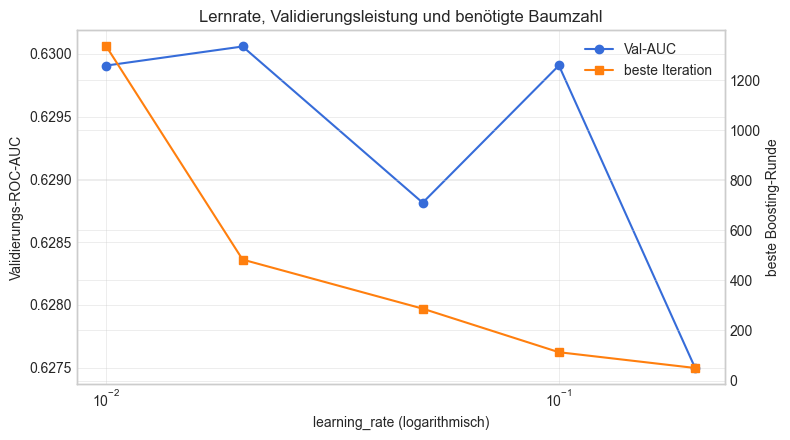

In [9]:
plot_df = group_table("Lernrate").copy()
plot_df["learning_rate"] = plot_df["Konfiguration"].str.split("=").str[1].astype(float)
plot_df = plot_df.sort_values("learning_rate")

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(plot_df["learning_rate"], plot_df["AUC Val"], marker="o", label="Val-AUC")
ax1.set_xscale("log")
ax1.set_xlabel("learning_rate (logarithmisch)")
ax1.set_ylabel("Validierungs-ROC-AUC")
ax2 = ax1.twinx()
ax2.plot(
    plot_df["learning_rate"], plot_df["beste Iteration"],
    marker="s", color="tab:orange", label="beste Iteration"
)
ax2.set_ylabel("beste Boosting-Runde")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="best")
ax1.set_title("Lernrate, Validierungsleistung und benötigte Baumzahl")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_lernrate_early_stopping.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Wechselwirkung `max_depth × min_child_weight`

`max_depth` begrenzt die mögliche Baumtiefe. `min_child_weight` verhindert kleine,
schwach gestützte Blätter. Erst die gemeinsame Betrachtung zeigt, ob größere Tiefe
durch konservativere Blätter ausgeglichen werden kann.

In [10]:
for depth in [1, 2, 3, 4]:
    for child_weight in [1, 10, 30, 50]:
        run_experiment(
            "Tiefe × Blattgewicht",
            f"depth={depth}, child={child_weight}",
            {"max_depth": depth, "min_child_weight": child_weight},
            verbose=True,
        )

depth_child_df = group_table("Tiefe × Blattgewicht")
depth_child_df.round(4)

depth=1, child=1                   Val-AUC 0.6266 | Gap +0.0062 | 2.0 s
depth=1, child=10                  Val-AUC 0.6267 | Gap +0.0063 | 1.9 s
depth=1, child=30                  Val-AUC 0.6272 | Gap +0.0054 | 1.9 s
depth=1, child=50                  Val-AUC 0.6273 | Gap +0.0049 | 3.0 s
depth=2, child=1                   Val-AUC 0.6284 | Gap +0.0320 | 2.2 s
depth=2, child=10                  Val-AUC 0.6287 | Gap +0.0308 | 2.1 s
depth=2, child=30                  Val-AUC 0.6288 | Gap +0.0282 | 2.1 s
depth=2, child=50                  Val-AUC 0.6279 | Gap +0.0285 | 2.1 s
depth=3, child=1                   Val-AUC 0.6280 | Gap +0.0686 | 2.3 s
depth=3, child=10                  Val-AUC 0.6270 | Gap +0.0636 | 2.2 s
depth=3, child=30                  Val-AUC 0.6285 | Gap +0.0575 | 2.3 s
depth=3, child=50                  Val-AUC 0.6282 | Gap +0.0554 | 2.2 s
depth=4, child=1                   Val-AUC 0.6251 | Gap +0.1260 | 2.4 s
depth=4, child=10                  Val-AUC 0.6258 | Gap +0.1067 

,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
0,"depth=1, child=1",0.6328,0.6266,0.2532,0.0634,0.1527,0.0348,0.0062,None,1.9675
1,"depth=1, child=10",0.6330,0.6267,0.2534,0.0635,0.1528,0.0348,0.0063,None,1.8624
2,"depth=1, child=30",0.6326,0.6272,0.2543,0.0638,0.1527,0.0348,0.0054,None,1.8808
3,"depth=1, child=50",0.6322,0.6273,0.2545,0.0638,0.1527,0.0348,0.0049,None,3.0037
4,"depth=2, child=1",0.6604,0.6284,0.2567,0.0630,0.1526,0.0348,0.0320,None,2.2181
5,"depth=2, child=10",0.6595,0.6287,0.2574,0.0630,0.1526,0.0348,0.0308,None,2.0580
6,"depth=2, child=30",0.6570,0.6288,0.2576,0.0632,0.1526,0.0348,0.0282,None,2.0663
7,"depth=2, child=50",0.6564,0.6279,0.2558,0.0636,0.1526,0.0348,0.0285,None,2.0852
8,"depth=3, child=1",0.6966,0.6280,0.2560,0.0626,0.1526,0.0348,0.0686,None,2.2847
9,"depth=3, child=10",0.6906,0.6270,0.2540,0.0617,0.1527,0.0348,0.0636,None,2.2350


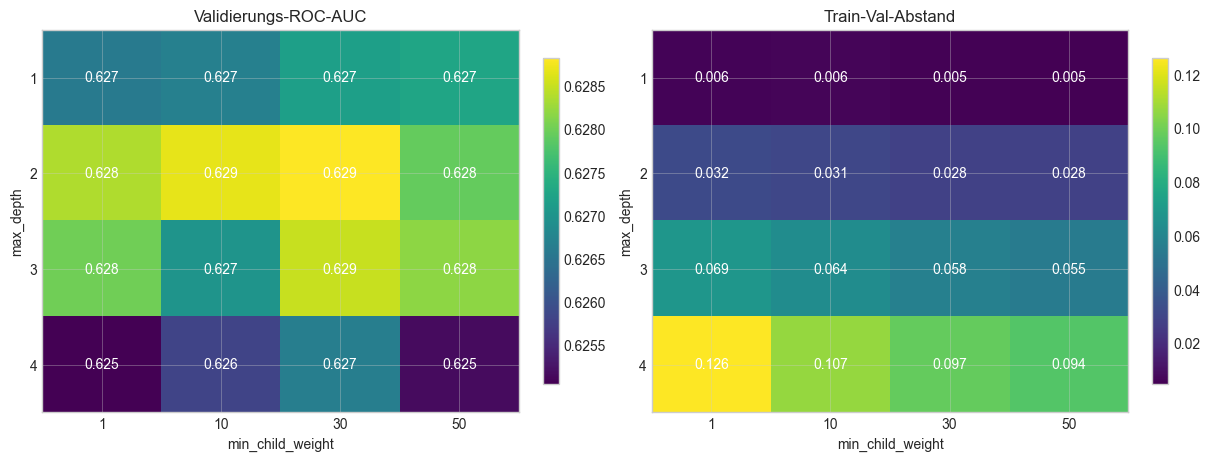

In [11]:
dc = pd.DataFrame([r for r in RESULTS if r["Gruppe"] == "Tiefe × Blattgewicht"])
dc["max_depth"] = dc["Konfiguration"].str.extract(r"depth=(\d+)").astype(int)
dc["min_child_weight"] = dc["Konfiguration"].str.extract(r"child=(\d+)").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "AUC Val", "Validierungs-ROC-AUC"),
    (axes[1], "Train-Val-Abstand", "Train-Val-Abstand"),
]:
    pivot = dc.pivot(index="max_depth", columns="min_child_weight", values=metric)
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_xlabel("min_child_weight")
    ax.set_ylabel("max_depth")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:.3f}", ha="center", va="center", color="white")
    fig.colorbar(im, ax=ax, shrink=0.85)

fig.savefig(OUTPUT_DIR / "02_depth_child_interaktion.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Regularisierung: `gamma`, `reg_alpha`, `reg_lambda`

Die drei Reihen verändern jeweils genau einen Parameter. Die gewählten Werte
liegen in realistischen Bereichen und ergänzen die bereits bekannten
Extremwert-Experimente.

In [12]:
regularization_values = {
    "gamma": [0.0, 0.05, 0.10, 0.50, 1.0, 2.0],
    "reg_alpha": [0.0, 0.001, 0.01, 0.10, 1.0],
    "reg_lambda": [0.10, 1.0, 5.0, 10.0, 20.0],
}

for parameter, values in regularization_values.items():
    for value in values:
        run_experiment(
            f"Regularisierung: {parameter}",
            f"{parameter}={value}",
            {parameter: value},
            verbose=True,
        )

reg_df = pd.DataFrame(
    [r for r in RESULTS if r["Gruppe"].startswith("Regularisierung:")]
)
reg_df[["Gruppe", "Konfiguration", "AUC Val", "Train-Val-Abstand", "Fit-Zeit [s]"]].round(4)

gamma=0.0                          Val-AUC 0.6288 | Gap +0.0282 | 2.1 s
gamma=0.05                         Val-AUC 0.6288 | Gap +0.0282 | 2.1 s
gamma=0.1                          Val-AUC 0.6288 | Gap +0.0282 | 2.0 s
gamma=0.5                          Val-AUC 0.6288 | Gap +0.0282 | 2.0 s
gamma=1.0                          Val-AUC 0.6288 | Gap +0.0282 | 2.0 s
gamma=2.0                          Val-AUC 0.6288 | Gap +0.0282 | 3.0 s
reg_alpha=0.0                      Val-AUC 0.6288 | Gap +0.0282 | 2.6 s
reg_alpha=0.001                    Val-AUC 0.6288 | Gap +0.0282 | 2.8 s
reg_alpha=0.01                     Val-AUC 0.6289 | Gap +0.0283 | 2.7 s
reg_alpha=0.1                      Val-AUC 0.6289 | Gap +0.0283 | 2.8 s
reg_alpha=1.0                      Val-AUC 0.6288 | Gap +0.0284 | 3.4 s
reg_lambda=0.1                     Val-AUC 0.6285 | Gap +0.0292 | 3.1 s
reg_lambda=1.0                     Val-AUC 0.6288 | Gap +0.0282 | 3.2 s
reg_lambda=5.0                     Val-AUC 0.6287 | Gap +0.0279 

,Gruppe,Konfiguration,AUC Val,Train-Val-Abstand,Fit-Zeit [s]
0,Regularisierung: gamma,gamma=0.0,0.6288,0.0282,2.0904
1,Regularisierung: gamma,gamma=0.05,0.6288,0.0282,2.0941
2,Regularisierung: gamma,gamma=0.1,0.6288,0.0282,2.0058
3,Regularisierung: gamma,gamma=0.5,0.6288,0.0282,2.0256
4,Regularisierung: gamma,gamma=1.0,0.6288,0.0282,2.0455
5,Regularisierung: gamma,gamma=2.0,0.6288,0.0282,3.0131
6,Regularisierung: reg_alpha,reg_alpha=0.0,0.6288,0.0282,2.6009
7,Regularisierung: reg_alpha,reg_alpha=0.001,0.6288,0.0282,2.8392
8,Regularisierung: reg_alpha,reg_alpha=0.01,0.6289,0.0283,2.7339
9,Regularisierung: reg_alpha,reg_alpha=0.1,0.6289,0.0283,2.8305


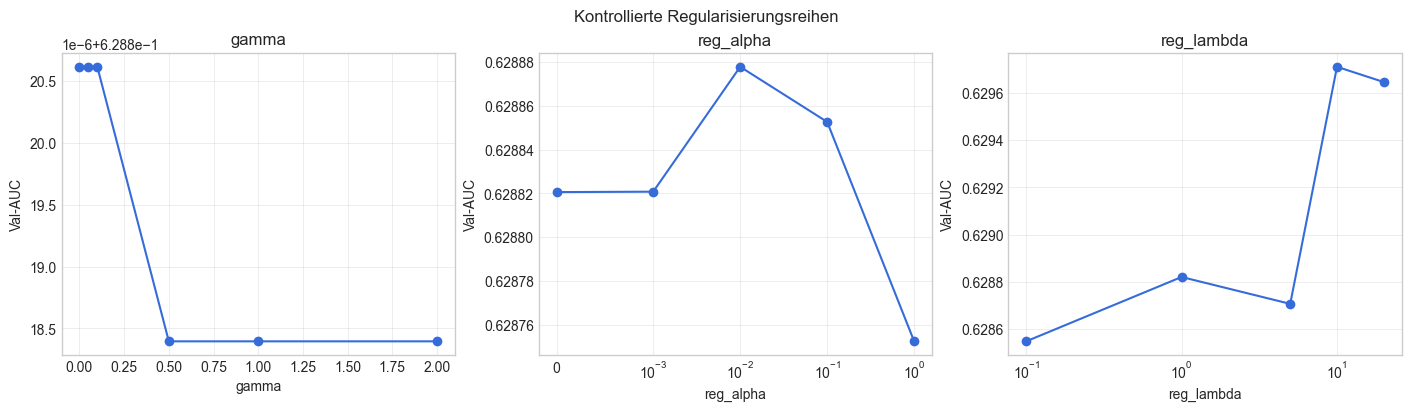

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, parameter in zip(axes, regularization_values):
    sub = reg_df[reg_df["Gruppe"] == f"Regularisierung: {parameter}"].copy()
    sub["Wert"] = sub["Konfiguration"].str.split("=").str[1].astype(float)
    sub = sub.sort_values("Wert")
    ax.plot(sub["Wert"], sub["AUC Val"], marker="o")
    ax.set_xlabel(parameter)
    ax.set_ylabel("Val-AUC")
    ax.set_title(parameter)
    if parameter != "gamma":
        ax.set_xscale("symlog", linthresh=0.001)
fig.suptitle("Kontrollierte Regularisierungsreihen")
fig.savefig(OUTPUT_DIR / "03_regularisierung.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Stochastische Regularisierung

`subsample` zieht Beobachtungen pro Boosting-Runde, `colsample_bytree` zieht
Features pro Baum. Die Matrix trennt reine Zeilen- oder Feature-Stichproben von
ihrer gemeinsamen Verwendung.

In [14]:
for row_fraction in [0.60, 0.80, 1.00]:
    for col_fraction in [0.60, 0.80, 1.00]:
        run_experiment(
            "Sampling",
            f"subsample={row_fraction}, colsample={col_fraction}",
            {"subsample": row_fraction, "colsample_bytree": col_fraction},
            verbose=True,
        )

sampling_df = pd.DataFrame([r for r in RESULTS if r["Gruppe"] == "Sampling"])
sampling_df[["Konfiguration", "AUC Val", "Train-Val-Abstand", "Fit-Zeit [s]"]].round(4)

subsample=0.6, colsample=0.6       Val-AUC 0.6308 | Gap +0.0266 | 3.3 s
subsample=0.6, colsample=0.8       Val-AUC 0.6304 | Gap +0.0273 | 3.2 s
subsample=0.6, colsample=1.0       Val-AUC 0.6294 | Gap +0.0288 | 3.7 s
subsample=0.8, colsample=0.6       Val-AUC 0.6295 | Gap +0.0270 | 2.8 s
subsample=0.8, colsample=0.8       Val-AUC 0.6288 | Gap +0.0282 | 2.8 s
subsample=0.8, colsample=1.0       Val-AUC 0.6288 | Gap +0.0301 | 2.9 s
subsample=1.0, colsample=0.6       Val-AUC 0.6296 | Gap +0.0254 | 2.2 s
subsample=1.0, colsample=0.8       Val-AUC 0.6293 | Gap +0.0257 | 2.1 s
subsample=1.0, colsample=1.0       Val-AUC 0.6293 | Gap +0.0261 | 2.1 s


,Konfiguration,AUC Val,Train-Val-Abstand,Fit-Zeit [s]
0,"subsample=0.6, colsample=0.6",0.6308,0.0266,3.2673
1,"subsample=0.6, colsample=0.8",0.6304,0.0273,3.2458
2,"subsample=0.6, colsample=1.0",0.6294,0.0288,3.6550
3,"subsample=0.8, colsample=0.6",0.6295,0.0270,2.8289
4,"subsample=0.8, colsample=0.8",0.6288,0.0282,2.8002
5,"subsample=0.8, colsample=1.0",0.6288,0.0301,2.8892
6,"subsample=1.0, colsample=0.6",0.6296,0.0254,2.2492
7,"subsample=1.0, colsample=0.8",0.6293,0.0257,2.1257
8,"subsample=1.0, colsample=1.0",0.6293,0.0261,2.1107


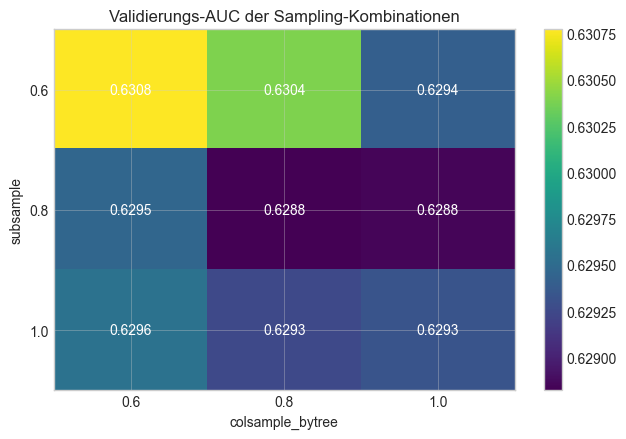

In [15]:
sampling_df["subsample"] = sampling_df["Konfiguration"].str.extract(r"subsample=([0-9.]+)").astype(float)
sampling_df["colsample"] = sampling_df["Konfiguration"].str.extract(r"colsample=([0-9.]+)").astype(float)
pivot = sampling_df.pivot(index="subsample", columns="colsample", values="AUC Val")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_xlabel("colsample_bytree")
ax.set_ylabel("subsample")
ax.set_title("Validierungs-AUC der Sampling-Kombinationen")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i, j]:.4f}", ha="center", va="center", color="white")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_sampling_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Klassenungleichgewicht

`scale_pos_weight` verändert die Gewichtung positiver Fälle. Deshalb werden nicht
nur Rangmetriken, sondern auch Log-Loss und Brier-Score ausgewiesen. Eine bessere
ROC-AUC bedeutet nicht automatisch gut kalibrierte Wahrscheinlichkeiten.

`max_delta_step` begrenzt die Größe eines einzelnen Blattupdates und kann bei
stark unausgeglichenen logistischen Problemen stabilisierend wirken.

In [16]:
class_ratio = (y_exp == 0).sum() / (y_exp == 1).sum()
spw_values = [1.0, float(np.sqrt(class_ratio)), 10.0, 15.0, float(class_ratio)]

for weight in spw_values:
    run_experiment(
        "Klassengewicht",
        f"scale_pos_weight={weight:.3f}",
        {"scale_pos_weight": weight},
        verbose=True,
    )

for delta in [0, 1, 5, 10]:
    run_experiment(
        "Max Delta Step",
        f"max_delta_step={delta}",
        {"max_delta_step": delta},
        verbose=True,
    )

imbalance_df = pd.DataFrame(
    [r for r in RESULTS if r["Gruppe"] in {"Klassengewicht", "Max Delta Step"}]
)
imbalance_df[[
    "Gruppe", "Konfiguration", "AUC Val", "Average Precision Val",
    "Log-Loss Val", "Brier Val", "Train-Val-Abstand"
]].round(5)

scale_pos_weight=1.000             Val-AUC 0.6288 | Gap +0.0282 | 2.7 s
scale_pos_weight=5.142             Val-AUC 0.6280 | Gap +0.0319 | 2.6 s
scale_pos_weight=10.000            Val-AUC 0.6284 | Gap +0.0330 | 2.6 s
scale_pos_weight=15.000            Val-AUC 0.6277 | Gap +0.0341 | 3.2 s
scale_pos_weight=26.435            Val-AUC 0.6262 | Gap +0.0366 | 2.5 s
max_delta_step=0                   Val-AUC 0.6288 | Gap +0.0282 | 2.5 s
max_delta_step=1                   Val-AUC 0.6289 | Gap +0.0283 | 2.5 s
max_delta_step=5                   Val-AUC 0.6288 | Gap +0.0282 | 2.7 s
max_delta_step=10                  Val-AUC 0.6288 | Gap +0.0282 | 3.1 s


,Gruppe,Konfiguration,AUC Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand
0,Klassengewicht,scale_pos_weight=1.000,0.62882,0.06319,0.15257,0.03480,0.02821
1,Klassengewicht,scale_pos_weight=5.142,0.62799,0.06262,0.23120,0.05141,0.03192
2,Klassengewicht,scale_pos_weight=10.000,0.62840,0.06338,0.34376,0.09022,0.03302
3,Klassengewicht,scale_pos_weight=15.000,0.62774,0.06319,0.45028,0.13523,0.03408
4,Klassengewicht,scale_pos_weight=26.435,0.62615,0.06265,0.65713,0.23223,0.03659
5,Max Delta Step,max_delta_step=0,0.62882,0.06319,0.15257,0.03480,0.02821
6,Max Delta Step,max_delta_step=1,0.62886,0.06332,0.15257,0.03480,0.02826
7,Max Delta Step,max_delta_step=5,0.62882,0.06319,0.15257,0.03480,0.02821
8,Max Delta Step,max_delta_step=10,0.62882,0.06319,0.15257,0.03480,0.02821


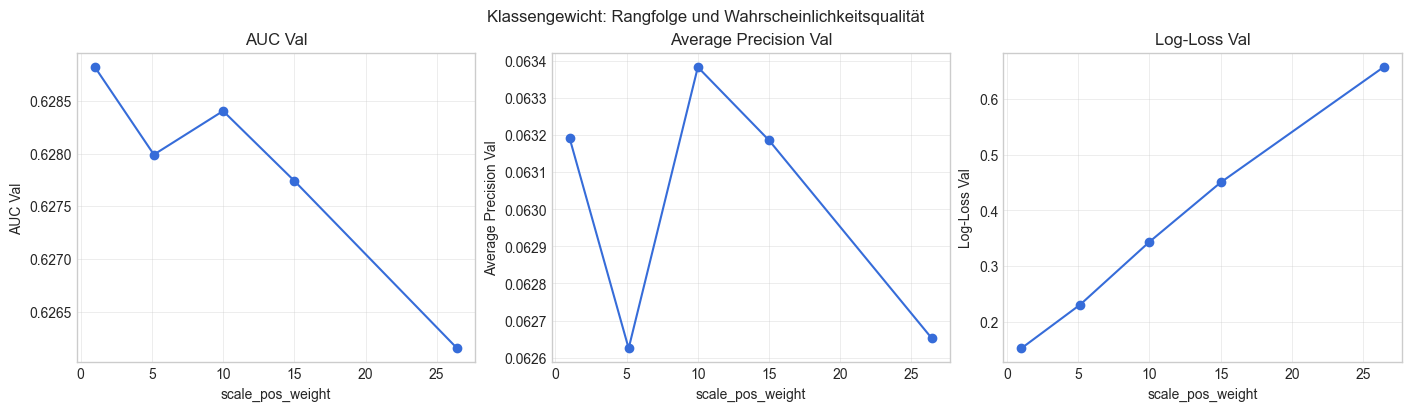

In [17]:
spw_df = imbalance_df[imbalance_df["Gruppe"] == "Klassengewicht"].copy()
spw_df["Gewicht"] = spw_df["Konfiguration"].str.split("=").str[1].astype(float)
spw_df = spw_df.sort_values("Gewicht")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, metric in zip(axes, ["AUC Val", "Average Precision Val", "Log-Loss Val"]):
    ax.plot(spw_df["Gewicht"], spw_df[metric], marker="o")
    ax.set_xlabel("scale_pos_weight")
    ax.set_ylabel(metric)
    ax.set_title(metric)
fig.suptitle("Klassengewicht: Rangfolge und Wahrscheinlichkeitsqualität")
fig.savefig(OUTPUT_DIR / "05_klassengewicht.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Baumwachstum: `depthwise` gegen `lossguide`

Bei `depthwise` wird die Komplexität über die Tiefe kontrolliert. `lossguide`
priorisiert den Split mit der größten Verlustreduktion und wird hier über
`max_leaves` begrenzt.

In [18]:
growth_variants = [
    ("depthwise, depth=2", {"grow_policy": "depthwise", "max_depth": 2}),
    ("depthwise, depth=4", {"grow_policy": "depthwise", "max_depth": 4}),
    ("lossguide, leaves=8",  {"grow_policy": "lossguide", "max_depth": 0, "max_leaves": 8}),
    ("lossguide, leaves=16", {"grow_policy": "lossguide", "max_depth": 0, "max_leaves": 16}),
    ("lossguide, leaves=32", {"grow_policy": "lossguide", "max_depth": 0, "max_leaves": 32}),
]

for name, params in growth_variants:
    run_experiment("Wachstumsstrategie", name, params, verbose=True)

group_table("Wachstumsstrategie").sort_values("AUC Val", ascending=False).round(4)

depthwise, depth=2                 Val-AUC 0.6288 | Gap +0.0282 | 2.7 s
depthwise, depth=4                 Val-AUC 0.6267 | Gap +0.0972 | 3.1 s
lossguide, leaves=8                Val-AUC 0.6281 | Gap +0.0757 | 3.1 s
lossguide, leaves=16               Val-AUC 0.6233 | Gap +0.1465 | 4.1 s
lossguide, leaves=32               Val-AUC 0.6206 | Gap +0.2378 | 4.5 s


,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
0,"depthwise, depth=2",0.6570,0.6288,0.2576,0.0632,0.1526,0.0348,0.0282,None,2.6634
2,"lossguide, leaves=8",0.7038,0.6281,0.2563,0.0621,0.1527,0.0348,0.0757,None,3.0797
1,"depthwise, depth=4",0.7239,0.6267,0.2533,0.0616,0.1528,0.0348,0.0972,None,3.0631
3,"lossguide, leaves=16",0.7698,0.6233,0.2465,0.0600,0.1530,0.0349,0.1465,None,4.1375
4,"lossguide, leaves=32",0.8584,0.6206,0.2412,0.0580,0.1536,0.0349,0.2378,None,4.5366


## 13. Histogrammauflösung: `max_bin`

Mehr Bins ermöglichen feinere Splitkandidaten, erhöhen aber Rechenzeit und
Speicherbedarf. Deshalb werden Leistung und Fit-Zeit gemeinsam betrachtet.

In [19]:
for bins in [64, 128, 256, 512]:
    run_experiment(
        "Histogramm-Bins",
        f"max_bin={bins}",
        {"max_bin": bins},
        verbose=True,
    )

group_table("Histogramm-Bins").sort_values("AUC Val", ascending=False).round(4)

max_bin=64                         Val-AUC 0.6294 | Gap +0.0275 | 2.7 s
max_bin=128                        Val-AUC 0.6291 | Gap +0.0278 | 2.4 s
max_bin=256                        Val-AUC 0.6288 | Gap +0.0282 | 2.4 s
max_bin=512                        Val-AUC 0.6285 | Gap +0.0290 | 2.5 s


,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
0,max_bin=64,0.6569,0.6294,0.2589,0.0631,0.1526,0.0348,0.0275,None,2.7102
1,max_bin=128,0.6569,0.6291,0.2582,0.0633,0.1526,0.0348,0.0278,None,2.4377
2,max_bin=256,0.6570,0.6288,0.2576,0.0632,0.1526,0.0348,0.0282,None,2.4496
3,max_bin=512,0.6575,0.6285,0.2570,0.0633,0.1526,0.0348,0.0290,None,2.4783


## 14. Vergleich der Kategorienbehandlung

Dieser Abschnitt ist bewusst vom Hyperparametervergleich getrennt. Die drei
Modelle verwenden dieselben Rohdaten und dieselben XGBoost-Basisparameter, aber
unterschiedliche Merkmalsdarstellungen:

- vollständiges One-Hot-Encoding,
- One-Hot-Encoding für kleine und Target Encoding für größere Kategorien,
- native XGBoost-Kategorienbehandlung.

Target Encoding wird innerhalb einer Pipeline angepasst, damit die
Zielinformation nicht vor dem Fit in die Validierungsdaten gelangt.

In [20]:
def evaluate_fitted_estimator(group, name, estimator, X_tr, y_tr, X_va, y_va, params):
    t0 = time.perf_counter()
    estimator.fit(X_tr, y_tr)
    elapsed = time.perf_counter() - t0
    p_tr = estimator.predict_proba(X_tr)[:, 1]
    p_va = estimator.predict_proba(X_va)[:, 1]
    model_for_iteration = estimator[-1] if isinstance(estimator, Pipeline) else estimator
    record = build_record(
        group, name, y_tr, p_tr, y_va, p_va, elapsed,
        model_for_iteration, params
    )
    RESULTS.append(record)
    MODELS[(group, name)] = estimator
    print(
        f"{name:<30} Val-AUC {record['AUC Val']:.4f} | "
        f"Gap {record['Train-Val-Abstand']:+.4f} | {elapsed:.1f} s"
    )
    return estimator, record


if RUN_ENCODING_COMPARISON:
    # 1) One-Hot: bereits transformierte Daten, aber neu gefittetes Modell
    onehot_model = XGBClassifier(**BASE_PARAMS)
    evaluate_fitted_estimator(
        "Encoding", "vollständiges One-Hot", onehot_model,
        X_exp, y_exp, X_val, y_val, {**BASE_PARAMS, "encoding": "onehot"}
    )

    # 2) Kombiniertes One-Hot-/Target-Encoding (falls in sklearn verfügbar)
    try:
        from sklearn.preprocessing import TargetEncoder

        cardinalities = X_exp_raw[cat_cols].nunique(dropna=False)
        low_card = cardinalities[cardinalities <= 20].index.tolist()
        high_card = cardinalities[cardinalities > 20].index.tolist()

        transformers = []
        if low_card:
            transformers.append((
                "cat_low",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                low_card,
            ))
        if high_card:
            transformers.append((
                "cat_high",
                TargetEncoder(target_type="binary", random_state=RANDOM_STATE),
                high_card,
            ))
        transformers.append(("num", "passthrough", num_cols + bin_cols))

        target_prep = ColumnTransformer(
            transformers=transformers,
            sparse_threshold=0,
            verbose_feature_names_out=False,
        )
        target_pipeline = Pipeline([
            ("prep", target_prep),
            ("model", XGBClassifier(**BASE_PARAMS)),
        ])
        evaluate_fitted_estimator(
            "Encoding", "One-Hot + Target Encoding", target_pipeline,
            X_exp_raw, y_exp, X_val_raw, y_val,
            {**BASE_PARAMS, "encoding": "onehot+target"},
        )
    except (ImportError, TypeError, ValueError) as exc:
        print("Target-Encoding-Variante übersprungen:", exc)

    # 3) Native Kategorien. Kategorieniveaus werden aus dem Experimenttraining übernommen.
    category_dtypes = {
        c: pd.CategoricalDtype(categories=pd.Index(X_exp_raw[c].astype(str).unique()))
        for c in cat_cols
    }

    def to_native_categories(frame):
        out = frame.copy()
        for column, dtype in category_dtypes.items():
            out[column] = out[column].astype(str).astype(dtype)
        return out

    X_exp_native = to_native_categories(X_exp_raw)
    X_val_native = to_native_categories(X_val_raw)
    native_params = {**BASE_PARAMS, "enable_categorical": True}
    native_model = XGBClassifier(**native_params)
    evaluate_fitted_estimator(
        "Encoding", "native Kategorien", native_model,
        X_exp_native, y_exp, X_val_native, y_val,
        {**native_params, "encoding": "native"},
    )

    # 4) Parameter der nativen Kategorienbehandlung
    for threshold in [2, 4, 8, 16]:
        params = {
            **native_params,
            "max_cat_to_onehot": threshold,
        }
        try:
            evaluate_fitted_estimator(
                "Native Kategorieparameter",
                f"max_cat_to_onehot={threshold}",
                XGBClassifier(**params),
                X_exp_native, y_exp, X_val_native, y_val,
                {**params, "encoding": "native"},
            )
        except (TypeError, ValueError) as exc:
            print(f"max_cat_to_onehot={threshold} übersprungen: {exc}")

    for threshold in [8, 16, 32, 64]:
        params = {
            **native_params,
            "max_cat_threshold": threshold,
        }
        try:
            evaluate_fitted_estimator(
                "Native Kategorieparameter",
                f"max_cat_threshold={threshold}",
                XGBClassifier(**params),
                X_exp_native, y_exp, X_val_native, y_val,
                {**params, "encoding": "native"},
            )
        except (TypeError, ValueError) as exc:
            print(f"max_cat_threshold={threshold} übersprungen: {exc}")

    display(group_table("Encoding").sort_values("AUC Val", ascending=False).round(4))
    if any(r["Gruppe"] == "Native Kategorieparameter" for r in RESULTS):
        display(
            group_table("Native Kategorieparameter")
            .sort_values("AUC Val", ascending=False)
            .round(4)
        )
else:
    print("Encoding-Vergleich deaktiviert.")

vollständiges One-Hot          Val-AUC 0.6288 | Gap +0.0282 | 2.5 s
One-Hot + Target Encoding      Val-AUC 0.6273 | Gap +0.0307 | 4.1 s
native Kategorien              Val-AUC 0.6158 | Gap +0.0611 | 3.3 s
max_cat_to_onehot=2            Val-AUC 0.6158 | Gap +0.0611 | 3.5 s
max_cat_to_onehot=4            Val-AUC 0.6158 | Gap +0.0611 | 3.3 s
max_cat_to_onehot=8            Val-AUC 0.6163 | Gap +0.0599 | 3.4 s
max_cat_to_onehot=16           Val-AUC 0.6137 | Gap +0.0610 | 3.5 s
max_cat_threshold=8            Val-AUC 0.6207 | Gap +0.0455 | 3.4 s
max_cat_threshold=16           Val-AUC 0.6171 | Gap +0.0555 | 3.5 s
max_cat_threshold=32           Val-AUC 0.6155 | Gap +0.0595 | 3.5 s
max_cat_threshold=64           Val-AUC 0.6158 | Gap +0.0611 | 3.5 s


,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
0,vollständiges One-Hot,0.6570,0.6288,0.2576,0.0632,0.1526,0.0348,0.0282,None,2.5076
1,One-Hot + Target Encoding,0.6580,0.6273,0.2545,0.0625,0.1527,0.0348,0.0307,None,4.1080
2,native Kategorien,0.6769,0.6158,0.2316,0.0603,0.1533,0.0349,0.0611,None,3.2925


,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Brier Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
4,max_cat_threshold=8,0.6662,0.6207,0.2414,0.0608,0.1531,0.0348,0.0455,None,3.3814
5,max_cat_threshold=16,0.6726,0.6171,0.2342,0.0602,0.1533,0.0349,0.0555,None,3.4791
2,max_cat_to_onehot=8,0.6761,0.6163,0.2325,0.0605,0.1533,0.0349,0.0599,None,3.3674
0,max_cat_to_onehot=2,0.6769,0.6158,0.2316,0.0603,0.1533,0.0349,0.0611,None,3.4926
7,max_cat_threshold=64,0.6769,0.6158,0.2316,0.0603,0.1533,0.0349,0.0611,None,3.4667
1,max_cat_to_onehot=4,0.6769,0.6158,0.2316,0.0603,0.1533,0.0349,0.0611,None,3.3126
6,max_cat_threshold=32,0.6749,0.6155,0.2310,0.0601,0.1534,0.0349,0.0595,None,3.5055
3,max_cat_to_onehot=16,0.6747,0.6137,0.2274,0.0600,0.1534,0.0349,0.0610,None,3.5107


## 15. Optionaler Anhang: weitere Sampling- und Booster-Varianten

Diese Experimente sind nicht notwendig, um die zentrale Fragestellung zu
beantworten. Sie sind standardmäßig deaktiviert, weil DART deutlich langsamer
sein kann. Zum Aktivieren oben `RUN_ADVANCED_APPENDIX = True` setzen.

In [21]:
if RUN_ADVANCED_APPENDIX:
    advanced_variants = [
        ("colsample_bylevel=0.7", {"colsample_bylevel": 0.7}),
        ("colsample_bynode=0.7", {"colsample_bynode": 0.7}),
        ("beide Column-Samplings=0.7", {
            "colsample_bylevel": 0.7, "colsample_bynode": 0.7
        }),
        ("DART rate_drop=0.05", {"booster": "dart", "rate_drop": 0.05}),
        ("DART rate_drop=0.10", {"booster": "dart", "rate_drop": 0.10}),
        ("DART rate_drop=0.20", {"booster": "dart", "rate_drop": 0.20}),
    ]
    for name, params in advanced_variants:
        try:
            run_experiment("Erweiterte Varianten", name, params, verbose=True)
        except Exception as exc:
            print(f"{name} wurde von der installierten XGBoost-Version nicht ausgeführt: {exc}")
    display(group_table("Erweiterte Varianten").round(4))
else:
    print("Optionaler Anhang deaktiviert.")

Optionaler Anhang deaktiviert.


## 16. Gesamtübersicht der kontrollierten Experimente

Die Testdaten wurden bis hierhin nicht verwendet. Die Tabelle wird zusätzlich als
CSV exportiert.

In [22]:
all_results = save_results()
summary = (
    all_results
    .sort_values(["Gruppe", "AUC Val"], ascending=[True, False])
    [[
        "Gruppe", "Konfiguration", "AUC Train", "AUC Val", "Gini Val",
        "Average Precision Val", "Log-Loss Val", "Train-Val-Abstand",
        "beste Iteration", "Fit-Zeit [s]",
    ]]
)
summary.round(4)

,Gruppe,Konfiguration,AUC Train,AUC Val,Gini Val,Average Precision Val,Log-Loss Val,Train-Val-Abstand,beste Iteration,Fit-Zeit [s]
65,Encoding,vollständiges One-Hot,0.6570,0.6288,0.2576,0.0632,0.1526,0.0282,NaN,2.5076
66,Encoding,One-Hot + Target Encoding,0.6580,0.6273,0.2545,0.0625,0.1527,0.0307,NaN,4.1080
67,Encoding,native Kategorien,0.6769,0.6158,0.2316,0.0603,0.1533,0.0611,NaN,3.2925
61,Histogramm-Bins,max_bin=64,0.6569,0.6294,0.2589,0.0631,0.1526,0.0275,NaN,2.7102
62,Histogramm-Bins,max_bin=128,0.6569,0.6291,0.2582,0.0633,0.1526,0.0278,NaN,2.4377
...,...,...,...,...,...,...,...,...,...,...
56,Wachstumsstrategie,"depthwise, depth=2",0.6570,0.6288,0.2576,0.0632,0.1526,0.0282,NaN,2.6634
58,Wachstumsstrategie,"lossguide, leaves=8",0.7038,0.6281,0.2563,0.0621,0.1527,0.0757,NaN,3.0797
57,Wachstumsstrategie,"depthwise, depth=4",0.7239,0.6267,0.2533,0.0616,0.1528,0.0972,NaN,3.0631
59,Wachstumsstrategie,"lossguide, leaves=16",0.7698,0.6233,0.2465,0.0600,0.1530,0.1465,NaN,4.1375


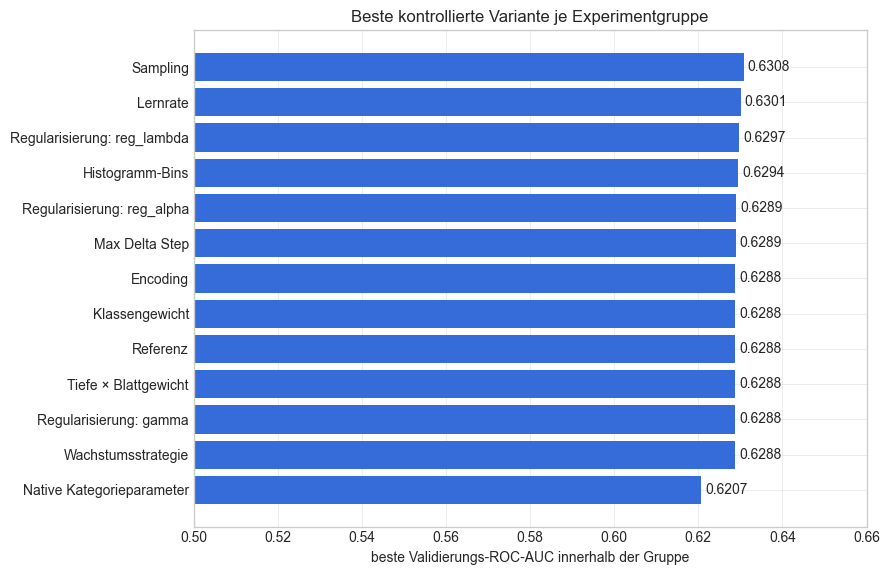

,Gruppe,Konfiguration,AUC Val,Train-Val-Abstand
38,Sampling,"subsample=0.6, colsample=0.6",0.6308,0.0266
4,Lernrate,learning_rate=0.02,0.6301,0.0203
36,Regularisierung: reg_lambda,reg_lambda=10.0,0.6297,0.0260
61,Histogramm-Bins,max_bin=64,0.6294,0.0275
30,Regularisierung: reg_alpha,reg_alpha=0.01,0.6289,0.0283
53,Max Delta Step,max_delta_step=1,0.6289,0.0283
65,Encoding,vollständiges One-Hot,0.6288,0.0282
47,Klassengewicht,scale_pos_weight=1.000,0.6288,0.0282
0,Referenz,Referenzkonfiguration,0.6288,0.0282
12,Tiefe × Blattgewicht,"depth=2, child=30",0.6288,0.0282


In [23]:
best_by_group = (
    all_results.loc[all_results.groupby("Gruppe")["AUC Val"].idxmax()]
    .sort_values("AUC Val", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, max(4.5, 0.45 * len(best_by_group))))
ax.barh(best_by_group["Gruppe"][::-1], best_by_group["AUC Val"][::-1])
ax.set_xlabel("beste Validierungs-ROC-AUC innerhalb der Gruppe")
ax.set_title("Beste kontrollierte Variante je Experimentgruppe")
ax.set_xlim(0.5, max(0.66, best_by_group["AUC Val"].max() + 0.01))
for i, value in enumerate(best_by_group["AUC Val"][::-1]):
    ax.text(value + 0.001, i, f"{value:.4f}", va="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_beste_varianten_je_gruppe.png", dpi=200, bbox_inches="tight")
plt.show()

best_by_group[["Gruppe", "Konfiguration", "AUC Val", "Train-Val-Abstand"]].round(4)

## 17. Abschließende Randomized Search

Die Suche kombiniert die zuvor einzeln begründeten Parameterbereiche. Sie läuft
ausschließlich auf der Experimentstichprobe und verwendet stratifizierte
Kreuzvalidierung. `n_estimators` wird hier als normaler Suchparameter behandelt,
da fold-spezifisches Early Stopping innerhalb von `RandomizedSearchCV` ein
separates Validierungsset pro Fold erfordern würde.

In [24]:
if RUN_RANDOM_SEARCH:
    param_dist = {
        "n_estimators": randint(200, 1601),
        "learning_rate": loguniform(0.005, 0.15),
        "max_depth": randint(1, 6),
        "min_child_weight": randint(5, 61),
        "subsample": uniform(0.60, 0.40),
        "colsample_bytree": uniform(0.50, 0.50),
        "gamma": loguniform(1e-3, 2.0),
        "reg_alpha": loguniform(1e-4, 3.0),
        "reg_lambda": loguniform(0.05, 20.0),
        "max_bin": [128, 256, 512],
    }

    cv = StratifiedKFold(
        n_splits=CFG["cv_splits"], shuffle=True, random_state=RANDOM_STATE
    )
    search_estimator = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    search = RandomizedSearchCV(
        estimator=search_estimator,
        param_distributions=param_dist,
        n_iter=CFG["search_iter"],
        scoring="roc_auc",
        cv=cv,
        refit=True,
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=2,
        return_train_score=True,
    )

    print(
        f"Geplante Fits: {CFG['search_iter']} × {CFG['cv_splits']} = "
        f"{CFG['search_iter'] * CFG['cv_splits']}"
    )
    t0 = time.perf_counter()
    search.fit(X_exp, y_exp)
    search_elapsed = time.perf_counter() - t0

    print(f"Suchdauer: {search_elapsed / 60:.1f} min")
    print(f"Beste mittlere CV-AUC: {search.best_score_:.4f}")
    print("Beste Parameter:")
    for key, value in sorted(search.best_params_.items()):
        print(f"  {key:<20} {value}")

    cv_results = pd.DataFrame(search.cv_results_)
    cv_results.to_csv(OUTPUT_DIR / "randomized_search_ergebnisse.csv", index=False)
else:
    search = None
    print("Randomized Search deaktiviert.")

Geplante Fits: 25 × 3 = 75
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.6872700594236812, gamma=1.3751068413926437, learning_rate=0.060285631437218844, max_bin=128, max_depth=5, min_child_weight=43, n_estimators=321, reg_alpha=0.0004993515273965266, reg_lambda=0.07081203049440488, subsample=0.9464704583099741; total time=   1.7s
[CV] END colsample_bytree=0.6872700594236812, gamma=1.3751068413926437, learning_rate=0.060285631437218844, max_bin=128, max_depth=5, min_child_weight=43, n_estimators=321, reg_alpha=0.0004993515273965266, reg_lambda=0.07081203049440488, subsample=0.9464704583099741; total time=   1.6s
[CV] END colsample_bytree=0.6872700594236812, gamma=1.3751068413926437, learning_rate=0.060285631437218844, max_bin=128, max_depth=5, min_child_weight=43, n_estimators=321, reg_alpha=0.0004993515273965266, reg_lambda=0.07081203049440488, subsample=0.9464704583099741; total time=   1.7s
[CV] END colsample_bytree=0.8005575058716043, gamma

In [25]:
if search is not None:
    param_cols = [c for c in cv_results.columns if c.startswith("param_")]
    top10 = (
        cv_results.sort_values("rank_test_score")
        .head(10)[
            ["rank_test_score", "mean_train_score", "mean_test_score", "std_test_score", "mean_fit_time"]
            + param_cols
        ]
        .reset_index(drop=True)
    )
    display(top10.round(4))

,rank_test_score,mean_train_score,mean_test_score,std_test_score,mean_fit_time,param_colsample_bytree,param_gamma,param_learning_rate,param_max_bin,param_max_depth,param_min_child_weight,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample
0,1,0.6620,0.6239,0.0066,4.3886,0.5172,1.0039,0.0121,256,2,8,902,0.5902,0.7400,0.7581
1,2,0.6893,0.6238,0.0060,5.2122,0.8006,0.2175,0.0054,256,4,34,1005,0.0001,19.0882,0.8470
2,3,0.7287,0.6236,0.0080,2.8599,0.5157,0.1261,0.0146,256,5,27,430,0.0069,4.6234,0.6915
3,4,0.6559,0.6234,0.0061,5.5770,0.5385,0.0090,0.0087,256,2,49,1212,0.7973,6.1684,0.6746
4,5,0.6655,0.6230,0.0061,4.9109,0.8058,0.0011,0.0054,512,3,46,899,0.0044,0.7686,0.9141
5,6,0.7018,0.6227,0.0071,2.9189,0.8459,0.1420,0.0107,128,4,37,597,0.0029,4.3791,0.8599
6,7,0.6437,0.6210,0.0056,1.6769,0.9828,0.4662,0.0141,128,2,24,291,0.0093,0.1039,0.7981
7,8,0.6431,0.6208,0.0064,4.7754,0.7352,1.7632,0.0194,512,1,13,1347,0.0188,3.2323,0.9433
8,9,0.6386,0.6205,0.0058,1.5049,0.7589,0.5825,0.0498,128,1,54,350,0.0266,3.2318,0.6914
9,10,0.6806,0.6202,0.0072,6.1760,0.7594,0.2093,0.0172,128,2,56,1491,0.0013,0.9836,0.7204


## 18. Finale Bewertung auf dem unangetasteten Testsplit

Erst jetzt werden das Referenzmodell und das durch Randomized Search ausgewählte
Modell auf `Train + Validierung` neu trainiert. Beide verwenden ein neu angepasstes
One-Hot-Encoding. Der Testsplit dient ausschließlich dieser einmaligen
Schlussbewertung.

In [26]:
X_train_val_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_train_val = np.concatenate([y_train, y_val])

final_onehot = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", min_frequency=50, sparse_output=True),
            cat_cols,
        ),
        ("num", "passthrough", num_cols + bin_cols),
    ],
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

X_train_val = final_onehot.fit_transform(X_train_val_raw)
X_test = final_onehot.transform(X_test_raw)

final_configs = [("Referenzmodell", BASE_PARAMS)]
if search is not None:
    final_configs.append((
        "Randomized-Search-Modell",
        {
            "objective": "binary:logistic",
            "eval_metric": "auc",
            "tree_method": "hist",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
            "verbosity": 0,
            **search.best_params_,
        },
    ))

final_rows = []
final_probabilities = {}
for name, params in final_configs:
    model = XGBClassifier(**params)
    t0 = time.perf_counter()
    model.fit(X_train_val, y_train_val)
    elapsed = time.perf_counter() - t0
    p_train = model.predict_proba(X_train_val)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]
    auc_train = roc_auc_score(y_train_val, p_train)
    auc_test = roc_auc_score(y_test, p_test)
    final_rows.append({
        "Modell": name,
        "AUC Train+Val": auc_train,
        "AUC Test": auc_test,
        "Gini Test": 2 * auc_test - 1,
        "Average Precision Test": average_precision_score(y_test, p_test),
        "Log-Loss Test": log_loss(y_test, np.clip(p_test, 1e-7, 1 - 1e-7)),
        "Brier Test": brier_score_loss(y_test, p_test),
        "Train-Test-Abstand": auc_train - auc_test,
        "Fit-Zeit [s]": elapsed,
    })
    final_probabilities[name] = p_test

final_results = pd.DataFrame(final_rows)
final_results.to_csv(OUTPUT_DIR / "finale_testergebnisse.csv", index=False)
final_results.round(5)

,Modell,AUC Train+Val,AUC Test,Gini Test,Average Precision Test,Log-Loss Test,Brier Test,Train-Test-Abstand,Fit-Zeit [s]
0,Referenzmodell,0.64331,0.64284,0.28567,0.06714,0.15178,0.03474,0.00047,8.68965
1,Randomized-Search-Modell,0.64041,0.64102,0.28205,0.06808,0.15188,0.03474,-0.00062,19.62378


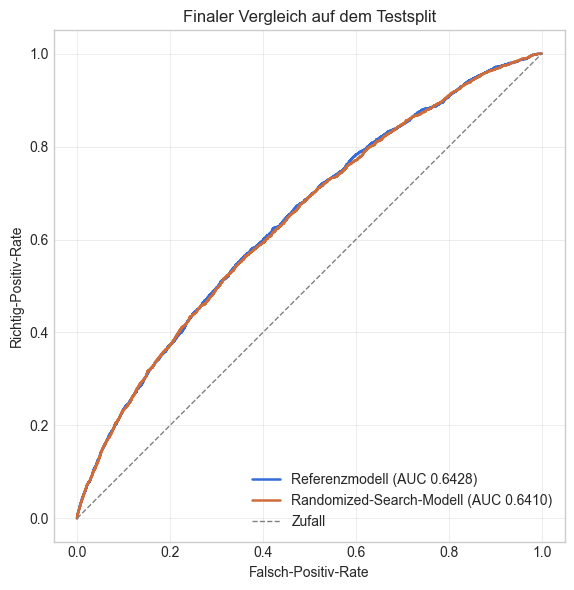

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 6.0))
for name, probabilities in final_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    ax.plot(fpr, tpr, linewidth=1.8, label=f"{name} (AUC {auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1, label="Zufall")
ax.set_xlabel("Falsch-Positiv-Rate")
ax.set_ylabel("Richtig-Positiv-Rate")
ax.set_title("Finaler Vergleich auf dem Testsplit")
ax.legend(loc="lower right")
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_finale_roc_kurven.png", dpi=200, bbox_inches="tight")
plt.show()

## 19. Automatische Stichpunkte für das Logbuch

Die folgende Zelle gibt die wichtigsten Ergebnisse als Ausgangspunkt für die
schriftliche Dokumentation aus. Die Aussagen sollten anschließend noch um die
inhaltliche Interpretation der beobachteten Parameterwirkungen ergänzt werden.

In [28]:
print("KONTROLLIERTE EXPERIMENTE")
for _, row in best_by_group.sort_values("AUC Val", ascending=False).iterrows():
    print(
        f"- {row['Gruppe']}: beste Variante '{row['Konfiguration']}' "
        f"mit Val-AUC {row['AUC Val']:.4f}, Gini {row['Gini Val']:.4f} "
        f"und Train-Val-Abstand {row['Train-Val-Abstand']:+.4f}."
    )

if search is not None:
    print(f"\nRANDOMIZED SEARCH\n- Beste mittlere CV-AUC: {search.best_score_:.4f}.")

print("\nFINALE TESTBEWERTUNG")
for _, row in final_results.iterrows():
    print(
        f"- {row['Modell']}: Test-AUC {row['AUC Test']:.4f}, "
        f"Gini {row['Gini Test']:.4f}, AP {row['Average Precision Test']:.4f}, "
        f"Train-Test-Abstand {row['Train-Test-Abstand']:+.4f}."
    )

KONTROLLIERTE EXPERIMENTE
- Sampling: beste Variante 'subsample=0.6, colsample=0.6' mit Val-AUC 0.6308, Gini 0.2615 und Train-Val-Abstand +0.0266.
- Lernrate: beste Variante 'learning_rate=0.02' mit Val-AUC 0.6301, Gini 0.2601 und Train-Val-Abstand +0.0203.
- Regularisierung: reg_lambda: beste Variante 'reg_lambda=10.0' mit Val-AUC 0.6297, Gini 0.2594 und Train-Val-Abstand +0.0260.
- Histogramm-Bins: beste Variante 'max_bin=64' mit Val-AUC 0.6294, Gini 0.2589 und Train-Val-Abstand +0.0275.
- Regularisierung: reg_alpha: beste Variante 'reg_alpha=0.01' mit Val-AUC 0.6289, Gini 0.2578 und Train-Val-Abstand +0.0283.
- Max Delta Step: beste Variante 'max_delta_step=1' mit Val-AUC 0.6289, Gini 0.2577 und Train-Val-Abstand +0.0283.
- Encoding: beste Variante 'vollständiges One-Hot' mit Val-AUC 0.6288, Gini 0.2576 und Train-Val-Abstand +0.0282.
- Klassengewicht: beste Variante 'scale_pos_weight=1.000' mit Val-AUC 0.6288, Gini 0.2576 und Train-Val-Abstand +0.0282.
- Referenz: beste Variante 'Re

## Methodische Grenzen

- Häufiges Vergleichen auf demselben Validierungssplit kann langfristig zu einer
  indirekten Anpassung an diesen Split führen.
- Im Modus `normal` wird die Randomized Search nur auf einer Teilmenge ausgeführt.
  Die Rangfolge der Kombinationen muss nicht exakt auf den vollständigen
  Trainingsdaten erhalten bleiben.
- Die Einzelexperimente verändern kontrolliert einen beziehungsweise zwei
  Parameter. Höherdimensionale Wechselwirkungen werden erst durch die
  Randomized Search teilweise berücksichtigt.
- `scale_pos_weight` kann Rangmetriken und die Skala der vorhergesagten
  Wahrscheinlichkeiten unterschiedlich beeinflussen. Für den produktiven Einsatz
  wäre eine gesonderte Kalibrierungsanalyse erforderlich.
- Ein geringer AUC-Unterschied sollte gemeinsam mit CV-Streuung, Laufzeit,
  Modellkomplexität und Train-Test-Abstand beurteilt werden.